💾 Generating Fairness & Bias Audit Graph (Including 128K)...
✅ Saved: ../reports/bias_audit_metrics.csv and bias_audit_chart.png


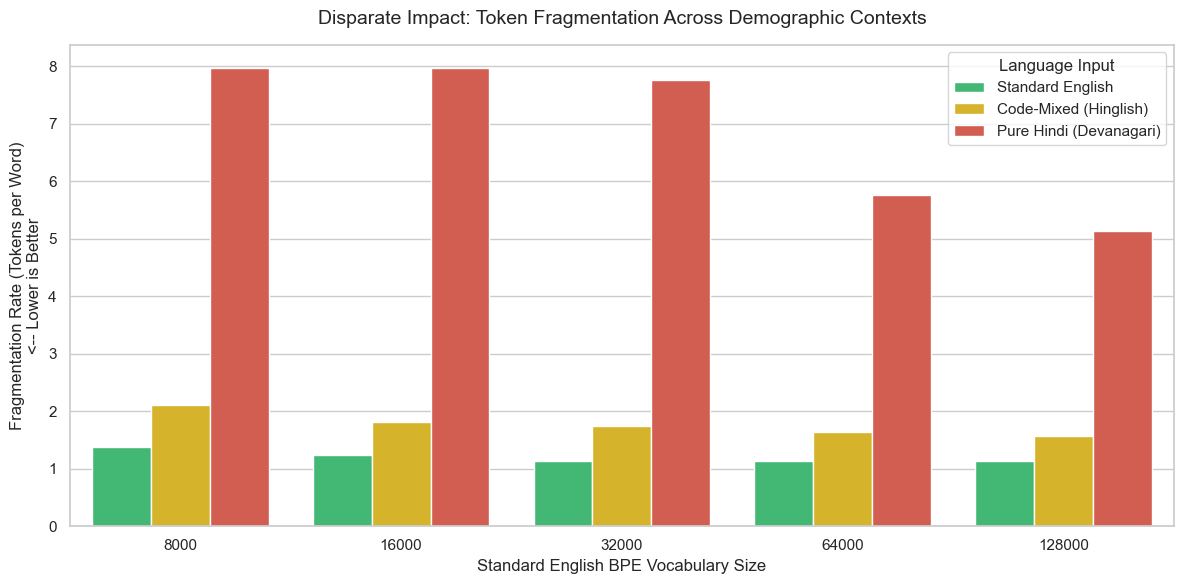

In [11]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys

sys.path.append(os.path.abspath('../src'))
from bpe import BPETokenizer

print("💾 Generating Fairness & Bias Audit Graph (Including 128K)...")

datasets = {
    "Standard English": [
        "I am going to the market to buy some fresh vegetables.",
        "The weather is really beautiful today, let us go outside.",
        "Machine learning requires a lot of computational power."
    ],
    "Code-Mixed (Hinglish)": [
        "Main market ja raha hu fresh vegetables kharidne.",
        "Aaj weather bahot beautiful hai, chalo bahar chalte hain.",
        "Machine learning train karne ke liye massive compute power chahiye."
    ],
    "Pure Hindi (Devanagari)": [
        "मैं ताजी सब्जियां खरीदने बाजार जा रहा हूं।",
        "आज मौसम बहुत सुहावना है, चलो बाहर चलते हैं।",
        "मशीन लर्निंग के लिए बहुत अधिक कम्प्यूटेशनल शक्ति की आवश्यकता होती है।"
    ]
}

target_sizes = [8000, 16000, 32000, 64000, 128000]
bias_metrics = []

for size in target_sizes:
    std_bpe = BPETokenizer()
    std_bpe.load(f'../vocabs/bpe_{size}.json')
    
    for language, sentences in datasets.items():
        total_words = 0
        total_tokens = 0
        
        for text in sentences:
            total_words += len(text.split())
            total_tokens += len(std_bpe.encode(text)['tokens'])
        
        bias_metrics.append({
            "Vocabulary Size": size,
            "Language Context": language,
            "Tokens per Word": round(total_tokens / total_words, 2)
        })

df_bias = pd.DataFrame(bias_metrics)
df_bias.to_csv('../reports/bias_audit_metrics.csv', index=False)

plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")
sns.barplot(data=df_bias, x="Vocabulary Size", y="Tokens per Word", hue="Language Context", palette=["#2ecc71", "#f1c40f", "#e74c3c"])

plt.title("Disparate Impact: Token Fragmentation Across Demographic Contexts", fontsize=14, pad=15)
plt.ylabel("Fragmentation Rate (Tokens per Word)\n<-- Lower is Better", fontsize=12)
plt.xlabel("Standard English BPE Vocabulary Size", fontsize=12)
plt.legend(title="Language Input")

plt.tight_layout()
plt.savefig('../reports/bias_audit_chart.png', dpi=300)
print("✅ Saved: ../reports/bias_audit_metrics.csv and bias_audit_chart.png")
plt.show()